In [1]:
# All the tools we need
import pandas as pd          # for loading and cleaning data
import numpy as np           # for math/numbers
import matplotlib.pyplot as plt  # for charts
import seaborn as sns        # for prettier charts

# Make charts show up inside the notebook
%matplotlib inline

# Make charts look clean
sns.set_theme(style="darkgrid")
print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load the CSV file into a DataFrame (like a table)
df = pd.read_csv("myanilist.csv")

# See how big the dataset is (rows, columns)
print("Shape:", df.shape)

# Preview the first 5 rows
df.head()

Shape: (21272, 21)


,ID,Title_Romaji,Title_English,Title_Native,Type,Format,Genres,Episodes,Season,Season_Year,...,End,Source,Country,Studios,Authors_Staff,Status,Average_Score,Mean_Score,Popularity,Favourites
0,16498,Shingeki no Kyojin,Attack on Titan,進撃の巨人,ANIME,TV,"Action, Drama, Fantasy, Mystery",25.0,SPRING,2013.0,...,2013-9-28,MANGA,JP,WIT STUDIO,"Tetsurou Araki (Director), Yasuko Kobayashi (S...",FINISHED,84.0,84.0,859225,53508
1,101922,Kimetsu no Yaiba,Demon Slayer: Kimetsu no Yaiba,鬼滅の刃,ANIME,TV,"Action, Adventure, Drama, Fantasy, Supernatural",26.0,SPRING,2019.0,...,2019-9-28,MANGA,JP,ufotable,"Koyoharu Gotouge (Original Creator), Gou Shiin...",FINISHED,83.0,83.0,814415,41891
2,1535,DEATH NOTE,Death Note,DEATH NOTE,ANIME,TV,"Mystery, Psychological, Supernatural, Thriller",37.0,FALL,2006.0,...,2007-6-27,MANGA,JP,MADHOUSE,"Aya Hirano (Insert Song Performance), Takeshi ...",FINISHED,84.0,84.0,781252,42700
3,113415,Jujutsu Kaisen,JUJUTSU KAISEN,呪術廻戦,ANIME,TV,"Action, Drama, Supernatural",24.0,FALL,2020.0,...,2021-3-27,MANGA,JP,MAPPA,"Gege Akutami (Original Creator), Hiroshi Seko ...",FINISHED,85.0,85.0,765997,49463
4,21459,Boku no Hero Academia,My Hero Academia,僕のヒーローアカデミア,ANIME,TV,"Action, Adventure, Comedy",13.0,SPRING,2016.0,...,2016-6-26,MANGA,JP,bones,"Kouhei Horikoshi (Original Creator), Yousuke K...",FINISHED,76.0,76.0,732029,20875


In [3]:
# See all column names and their data types
print(df.dtypes)
print()

# Count missing values in each column
print("Missing values:")
print(df.isnull().sum())


ID                 int64
Title_Romaji      object
Title_English     object
Title_Native      object
Type              object
Format            object
Genres            object
Episodes         float64
Season            object
Season_Year      float64
Start             object
End               object
Source            object
Country           object
Studios           object
Authors_Staff     object
Status            object
Average_Score    float64
Mean_Score       float64
Popularity         int64
Favourites         int64
dtype: object

Missing values:
ID                   0
Title_Romaji         0
Title_English    11391
Title_Native       211
Type                 0
Format              95
Genres            2886
Episodes           776
Season            7473
Season_Year       7473
Start                0
End                  0
Source            2460
Country              0
Studios           9226
Authors_Staff     3035
Status               0
Average_Score     5541
Mean_Score         692
Popular

In [5]:
df = df.dropna(subset=["Title_Romaji", "Genres"])

df["Average_Score"] = pd.to_numeric(df["Average_Score"], errors="coerce")
df["Average_Score"] = df["Average_Score"].fillna(df["Average_Score"].mean())

df = df.reset_index(drop=True)
print("Clean dataset shape:", df.shape)
df.head()

Clean dataset shape: (18386, 21)


C:\Users\nagar\AppData\Local\Temp\ipykernel_12256\2021063454.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Average_Score"] = pd.to_numeric(df["Average_Score"], errors="coerce")
C:\Users\nagar\AppData\Local\Temp\ipykernel_12256\2021063454.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Average_Score"] = df["Average_Score"].fillna(df["Average_Score"].mean())


,ID,Title_Romaji,Title_English,Title_Native,Type,Format,Genres,Episodes,Season,Season_Year,...,End,Source,Country,Studios,Authors_Staff,Status,Average_Score,Mean_Score,Popularity,Favourites
0,16498,Shingeki no Kyojin,Attack on Titan,進撃の巨人,ANIME,TV,"Action, Drama, Fantasy, Mystery",25.0,SPRING,2013.0,...,2013-9-28,MANGA,JP,WIT STUDIO,"Tetsurou Araki (Director), Yasuko Kobayashi (S...",FINISHED,84.0,84.0,859225,53508
1,101922,Kimetsu no Yaiba,Demon Slayer: Kimetsu no Yaiba,鬼滅の刃,ANIME,TV,"Action, Adventure, Drama, Fantasy, Supernatural",26.0,SPRING,2019.0,...,2019-9-28,MANGA,JP,ufotable,"Koyoharu Gotouge (Original Creator), Gou Shiin...",FINISHED,83.0,83.0,814415,41891
2,1535,DEATH NOTE,Death Note,DEATH NOTE,ANIME,TV,"Mystery, Psychological, Supernatural, Thriller",37.0,FALL,2006.0,...,2007-6-27,MANGA,JP,MADHOUSE,"Aya Hirano (Insert Song Performance), Takeshi ...",FINISHED,84.0,84.0,781252,42700
3,113415,Jujutsu Kaisen,JUJUTSU KAISEN,呪術廻戦,ANIME,TV,"Action, Drama, Supernatural",24.0,FALL,2020.0,...,2021-3-27,MANGA,JP,MAPPA,"Gege Akutami (Original Creator), Hiroshi Seko ...",FINISHED,85.0,85.0,765997,49463
4,21459,Boku no Hero Academia,My Hero Academia,僕のヒーローアカデミア,ANIME,TV,"Action, Adventure, Comedy",13.0,SPRING,2016.0,...,2016-6-26,MANGA,JP,bones,"Kouhei Horikoshi (Original Creator), Yousuke K...",FINISHED,76.0,76.0,732029,20875


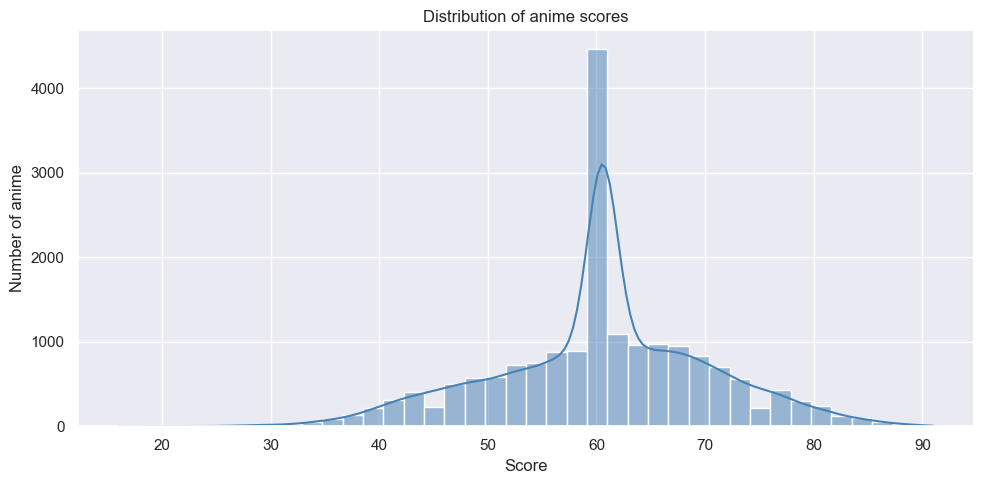

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Average_Score"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of anime scores")
plt.xlabel("Score")
plt.ylabel("Number of anime")
plt.tight_layout()
plt.show()

C:\Users\nagar\AppData\Local\Temp\ipykernel_12256\633065808.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")


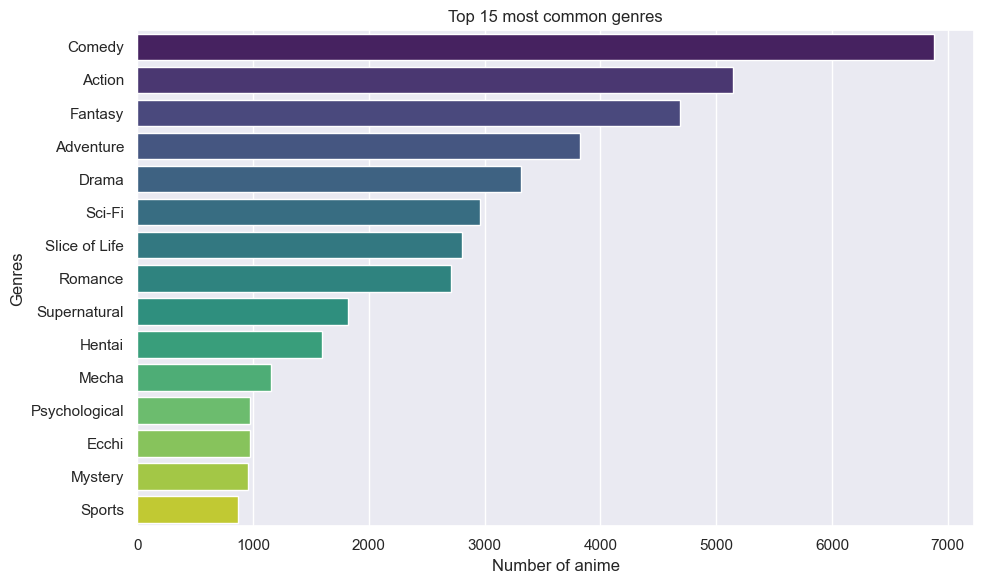

In [7]:
all_genres = df["Genres"].dropna().str.split(",").explode().str.strip()
top_genres = all_genres.value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title("Top 15 most common genres")
plt.xlabel("Number of anime")
plt.tight_layout()
plt.show()


In [8]:
top10 = df.nlargest(10, "Average_Score")[["Title_Romaji", "Average_Score", "Genres"]]
print("Top 10 highest rated anime:")
print(top10.to_string(index=False))

Top 10 highest rated anime:
                                 Title_Romaji  Average_Score                                 Genres
                            Sousou no Frieren           91.0              Adventure, Drama, Fantasy
                           Gintama: THE FINAL           91.0          Action, Comedy, Drama, Sci-Fi
Hagane no Renkinjutsushi: FULLMETAL ALCHEMIST           90.0      Action, Adventure, Drama, Fantasy
Hagane no Renkinjutsushi: FULLMETAL ALCHEMIST           90.0      Action, Adventure, Drama, Fantasy
                                     Gintama°           90.0          Action, Comedy, Drama, Sci-Fi
                         ONE PIECE FAN LETTER           90.0             Action, Adventure, Fantasy
                         HUNTER×HUNTER (2011)           89.0             Action, Adventure, Fantasy
                  Shingeki no Kyojin 3 Part 2           89.0        Action, Drama, Fantasy, Mystery
                                  Steins;Gate           89.0 Drama, Psyc

C:\Users\nagar\AppData\Local\Temp\ipykernel_12256\3873507265.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_score_by_genre.values,


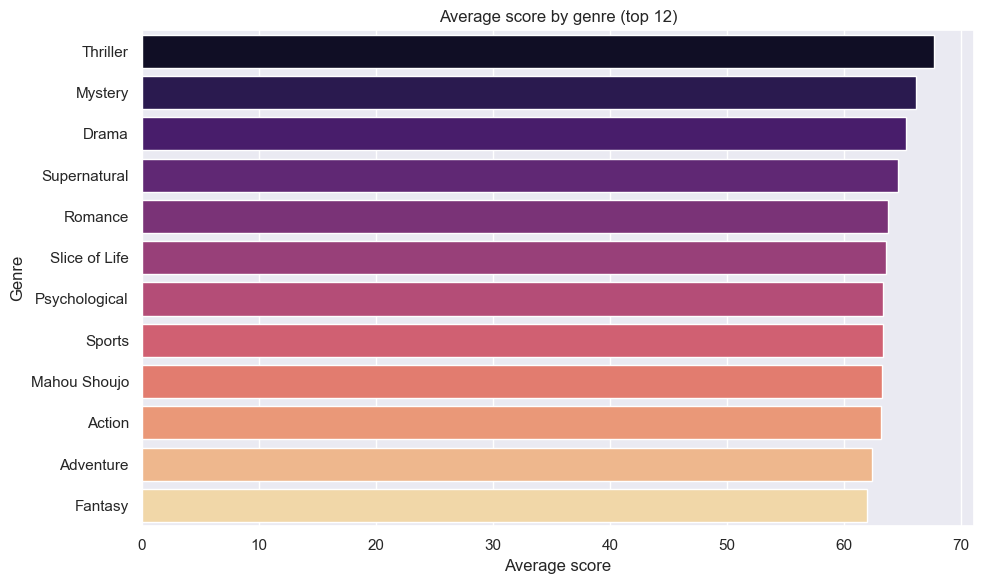

In [9]:
df_exploded = df.copy()
df_exploded["Genre"] = df_exploded["Genres"].str.split(",")
df_exploded = df_exploded.explode("Genre")
df_exploded["Genre"] = df_exploded["Genre"].str.strip()

avg_score_by_genre = (
    df_exploded.groupby("Genre")["Average_Score"]
    .mean()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_score_by_genre.values,
            y=avg_score_by_genre.index, palette="magma")
plt.title("Average score by genre (top 12)")
plt.xlabel("Average score")
plt.tight_layout()
plt.show()

In [10]:
# Remove hentai and deduplicate
df = df[~df["Genres"].str.contains("Hentai", na=False)]
df = df.drop_duplicates(subset=["Title_Romaji"])
df = df.reset_index(drop=True)
print("After filtering:", df.shape)

After filtering: (16691, 21)


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fill any remaining missing genres just in case
df["Genres"] = df["Genres"].fillna("")

# Convert genres into a numerical matrix
tfidf = TfidfVectorizer(token_pattern=r"[^,]+")
tfidf_matrix = tfidf.fit_transform(df["Genres"])

print("Matrix shape:", tfidf_matrix.shape)

Matrix shape: (16691, 35)


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate how similar every anime is to every other anime
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (16691, 16691)


In [28]:
def recommend(title, n=10):
    title_clean = title.lower().strip()
    
    if title_clean in indices:
        idx = indices[title_clean]
    else:
        matches = [t for t in indices.index if title_clean in t]
        if not matches:
            print(f"'{title}' not found. Closest titles:")
            close = df["Title_Romaji_Lower"].str.contains(title_clean[:4], na=False)
            print(df[close]["Title_Romaji"].head(5).to_string(index=False))
            return
        matches.sort(key=lambda x: abs(len(x) - len(title_clean)))
        idx = indices[matches[0]]
        print(f"Showing results for: '{df.loc[idx, 'Title_Romaji']}'")
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    
    anime_indices = [i[0] for i in sim_scores]
    similarity_values = [round(i[1], 3) for i in sim_scores]
    
    results = df[["Title_Romaji", "Genres", "Average_Score"]].iloc[anime_indices].copy()
    results["Similarity"] = similarity_values
    
    # normalize both scores to 0-1 range
    results["Norm_Score"] = results["Average_Score"] / 100
    results["Norm_Similarity"] = results["Similarity"] / results["Similarity"].max()
    
    # blend them — 70% similarity, 30% average score
    results["Final_Score"] = (results["Norm_Similarity"] * 0.7) + (results["Norm_Score"] * 0.3)
    
    return results[["Title_Romaji", "Genres", "Average_Score", "Similarity", "Final_Score"]].sort_values("Final_Score", ascending=False).reset_index(drop=True)

In [30]:
recommend("oshi no ko")

Showing results for: '[Oshi no Ko]'


,Title_Romaji,Genres,Average_Score,Similarity,Final_Score
0,[Oshi no Ko] 2nd Season,"Drama, Mystery, Psychological, Supernatural",85.000000,1.000,0.955000
1,Owarimonogatari,"Drama, Mystery, Psychological, Supernatural",84.000000,1.000,0.952000
2,Mawaru Penguindrum,"Drama, Mystery, Psychological, Supernatural",79.000000,1.000,0.937000
3,Hanamonogatari,"Drama, Mystery, Psychological, Supernatural",78.000000,1.000,0.934000
4,RE:cycle of the PENGUINDRUM: Kouhen - Boku wa ...,"Drama, Mystery, Psychological, Supernatural",73.000000,1.000,0.919000
5,RE:cycle of the PENGUINDRUM: Zenpen - Kimi no ...,"Drama, Mystery, Psychological, Supernatural",71.000000,1.000,0.913000
6,Red Garden,"Drama, Mystery, Psychological, Supernatural",66.000000,1.000,0.898000
7,serial experiments lain,"Drama, Mystery, Psychological, Sci-Fi, Superna...",80.000000,0.938,0.896600
8,Shuangsheng Lingtan,"Drama, Mystery, Psychological, Supernatural",65.000000,1.000,0.895000
9,[Oshi no Ko] 3rd Season,"Drama, Mystery, Psychological, Supernatural",60.532125,1.000,0.881596
